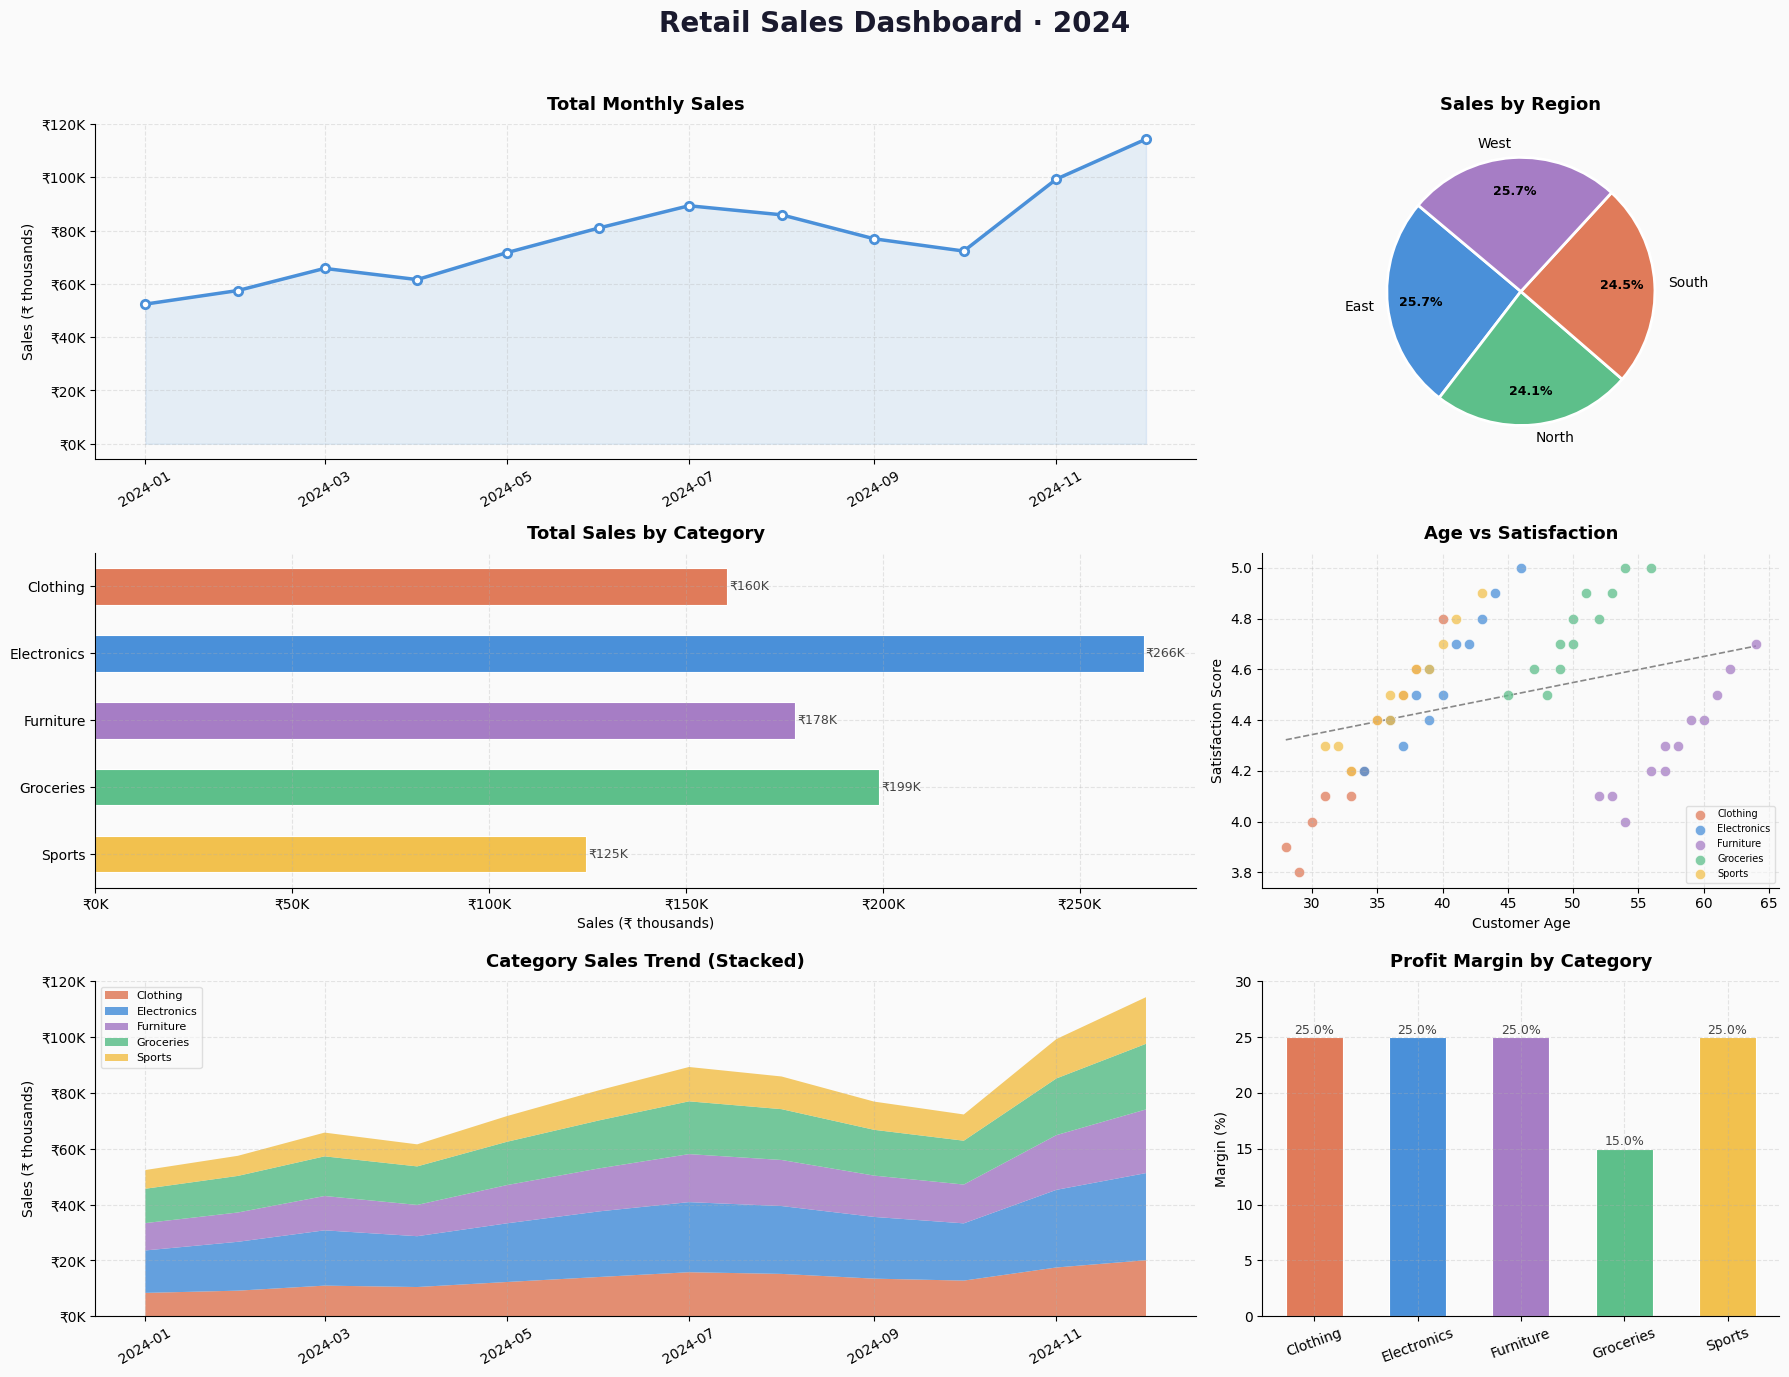

✓ Dashboard saved as sales_dashboard.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv("clean_dataset.csv", parse_dates=["date"])

# ── Aggregations ──────────────────────────────────────────────────────────────
monthly_sales   = df.groupby("date")["sales"].sum().reset_index()
category_sales  = df.groupby("category")["sales"].sum()
region_sales    = df.groupby("region")["sales"].sum()
cat_month       = df.groupby(["date", "category"])["sales"].sum().unstack()

# ── Palette ───────────────────────────────────────────────────────────────────
COLORS = {
    "Electronics": "#4A90D9",
    "Clothing":    "#E07B5A",
    "Groceries":   "#5DBF8A",
    "Furniture":   "#A67DC5",
    "Sports":      "#F2C14E",
}
REGION_COLORS = ["#4A90D9", "#5DBF8A", "#E07B5A", "#A67DC5"]

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor":   "#FAFAFA",
})

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Retail Sales Dashboard · 2024", fontsize=20, fontweight="bold",
             color="#1A1A2E", y=0.98)

# ── 1. Line chart – total monthly sales ──────────────────────────────────────
ax1 = fig.add_subplot(3, 3, (1, 2))
ax1.plot(monthly_sales["date"], monthly_sales["sales"] / 1000,
         color="#4A90D9", linewidth=2.5, marker="o", markersize=6,
         markerfacecolor="white", markeredgewidth=2)
ax1.fill_between(monthly_sales["date"], monthly_sales["sales"] / 1000,
                 alpha=0.12, color="#4A90D9")
ax1.set_title("Total Monthly Sales", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("Sales (₹ thousands)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}K"))
ax1.tick_params(axis="x", rotation=30)

# ── 2. Pie chart – regional sales share ──────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 3)
wedges, texts, autotexts = ax2.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    colors=REGION_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax2.set_title("Sales by Region", fontsize=13, fontweight="bold", pad=10)

# ── 3. Horizontal bar – category sales ───────────────────────────────────────
ax3 = fig.add_subplot(3, 3, (4, 5))
bars = ax3.barh(
    category_sales.index,
    category_sales.values / 1000,
    color=[COLORS[c] for c in category_sales.index],
    edgecolor="white", linewidth=0.8, height=0.55,
)
for bar, val in zip(bars, category_sales.values):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"₹{val/1000:,.0f}K", va="center", fontsize=9, color="#444")
ax3.set_title("Total Sales by Category", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("Sales (₹ thousands)")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}K"))
ax3.invert_yaxis()

# ── 4. Scatter – customer age vs satisfaction ─────────────────────────────────
ax4 = fig.add_subplot(3, 3, 6)
for cat, grp in df.groupby("category"):
    ax4.scatter(grp["customer_age"], grp["customer_satisfaction"],
                label=cat, color=COLORS[cat], alpha=0.75, s=55, edgecolors="white", linewidth=0.5)
# trend line
z = np.polyfit(df["customer_age"], df["customer_satisfaction"], 1)
xline = np.linspace(df["customer_age"].min(), df["customer_age"].max(), 100)
ax4.plot(xline, np.poly1d(z)(xline), color="#888", linewidth=1.2, linestyle="--", zorder=0)
ax4.set_title("Age vs Satisfaction", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("Customer Age")
ax4.set_ylabel("Satisfaction Score")
ax4.legend(fontsize=7, loc="lower right", framealpha=0.6)

# ── 5. Stacked area – category sales over time ───────────────────────────────
ax5 = fig.add_subplot(3, 3, (7, 8))
ax5.stackplot(
    cat_month.index,
    [cat_month[c] / 1000 for c in cat_month.columns],
    labels=cat_month.columns,
    colors=[COLORS[c] for c in cat_month.columns],
    alpha=0.85,
)
ax5.set_title("Category Sales Trend (Stacked)", fontsize=13, fontweight="bold", pad=10)
ax5.set_ylabel("Sales (₹ thousands)")
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}K"))
ax5.tick_params(axis="x", rotation=30)
ax5.legend(loc="upper left", fontsize=8, framealpha=0.6)

# ── 6. Bar chart – profit margin by category ─────────────────────────────────
ax6 = fig.add_subplot(3, 3, 9)
cat_margin = (df.groupby("category")["profit"].sum() /
              df.groupby("category")["sales"].sum() * 100)
bars2 = ax6.bar(
    cat_margin.index,
    cat_margin.values,
    color=[COLORS[c] for c in cat_margin.index],
    edgecolor="white", linewidth=0.8, width=0.55,
)
for bar, val in zip(bars2, cat_margin.values):
    ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontsize=9, color="#444")
ax6.set_title("Profit Margin by Category", fontsize=13, fontweight="bold", pad=10)
ax6.set_ylabel("Margin (%)")
ax6.tick_params(axis="x", rotation=20)
ax6.set_ylim(0, cat_margin.max() * 1.2)

# ── Layout & export ───────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("sales_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Dashboard saved as sales_dashboard.png")
